# Feature Engineering Location Features

## K-Means Clustering

### Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns

# Set plot style for better visuals
sns.set(style="whitegrid")

# Load your specific dataset
# Assuming the file is in the same directory
df_stations = pd.read_csv('poi_bike_stations.csv')

print(f"Loaded {len(df_stations)} stations.")
df_stations.head()

Loaded 1042 stations.


,station_id,name,lat,lon,capacity,address,is_charging_station,nearby_distance,bus,subway,streetcar,train,all_public_transport,tourism,office,park,healthcare,education,food_drink,commercial
0,7000,Fort York Blvd / Capreol Ct,43.639832,-79.395954,47,Fort York Blvd / Capreol Ct,False,500.0,0,0,11,0,11,20,10,43,15,6,32,56
1,7001,Wellesley Station Green P,43.664964,-79.383550,23,Yonge / Wellesley,True,500.0,20,1,0,0,21,4,11,60,27,8,126,149
2,7002,St. George St / Bloor St W,43.667131,-79.399555,19,St. George St / Bloor St W,False,500.0,14,1,2,0,17,3,15,19,7,13,35,31
3,7003,Madison Ave / Bloor St W,43.667018,-79.402796,15,Madison Ave / Bloor St W,False,500.0,8,2,4,0,14,4,10,18,7,13,40,46
4,7005,King St W / York St,43.648001,-79.383177,26,King St W / York St,False,500.0,8,2,10,0,20,12,56,41,25,1,206,149


### Determine Optimal Clusters (The Elbow Method)

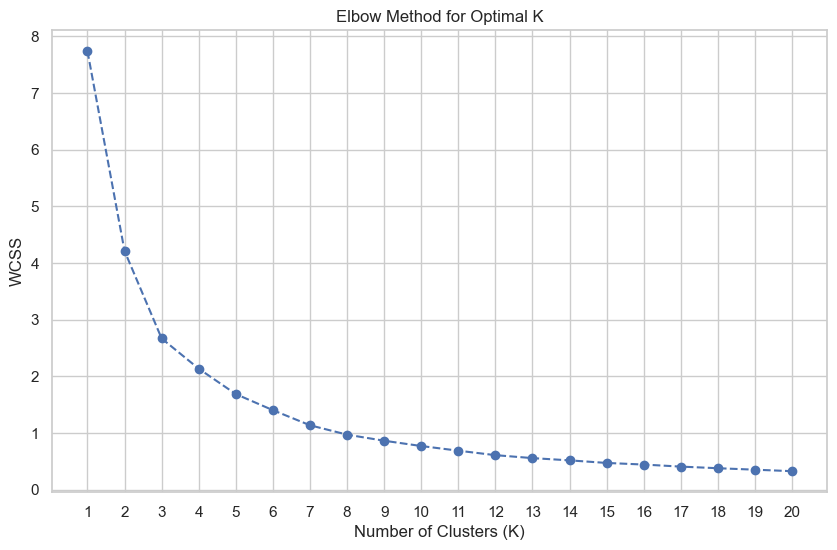

In [2]:
# 1. Extract Lat/Lon for clustering
# We strictly use these two columns for the spatial clustering
X = df_stations[['lat', 'lon']].copy()

# 2. Calculate WCSS (Within-Cluster Sum of Squares) for a range of K
wcss = []
k_range = range(1, 21) # Test K from 1 to 20

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# 3. Plot the Elbow Graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.grid(True)
plt.show()

### Apply K-Means Clustering

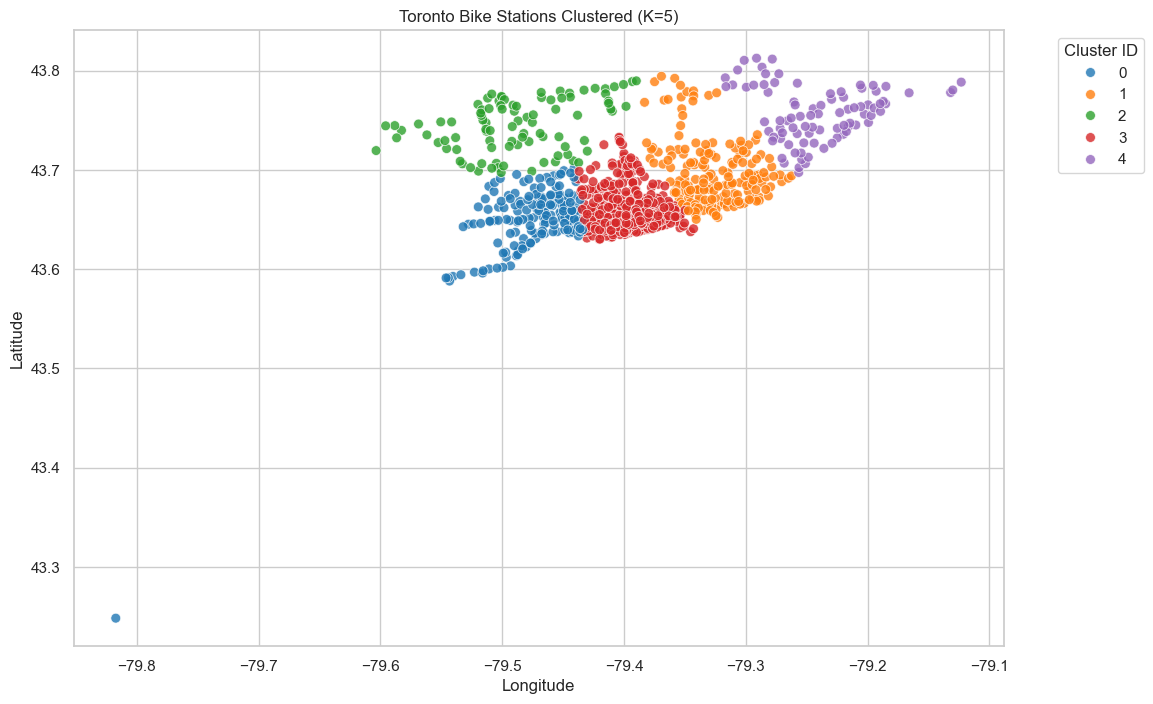

cluster_name
downtown       510
east_end       182
west_end       170
uptown          93
scarborough     87
Name: count, dtype: int64


In [3]:
# --- CONFIGURATION ---
OPTIMAL_K = 5
cluster_naming_map = {
    0: "west_end",
    1: "east_end",
    2: "uptown",
    3: "downtown",
    4: "scarborough"
}
# ---------------------

# Initialize and fit the model
kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)

# Create the cluster labels
# We use .copy() to avoid SettingWithCopy warnings
df_stations['cluster_id'] = kmeans.fit_predict(df_stations[['lat', 'lon']])
df_stations['cluster_name'] = df_stations['cluster_id'].map(cluster_naming_map)

# Visualize the clusters spatially
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_stations, x='lon', y='lat', 
    hue='cluster_id', palette='tab10', s=50, alpha=0.8
)
plt.title(f'Toronto Bike Stations Clustered (K={OPTIMAL_K})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Cluster ID')
plt.show()

print(df_stations['cluster_name'].value_counts())

### One-hot encode cluster data

In [4]:
df_stations = df_stations.drop(columns=['cluster_id'])
cluster_dummies = pd.get_dummies(df_stations['cluster_name'], prefix='cluster', drop_first=True, dtype=int)


df_stations_encoded = pd.concat([df_stations, cluster_dummies], axis=1)
df_stations_encoded.head()

,station_id,name,lat,lon,capacity,address,is_charging_station,nearby_distance,bus,subway,...,park,healthcare,education,food_drink,commercial,cluster_name,cluster_east_end,cluster_scarborough,cluster_uptown,cluster_west_end
0,7000,Fort York Blvd / Capreol Ct,43.639832,-79.395954,47,Fort York Blvd / Capreol Ct,False,500.0,0,0,...,43,15,6,32,56,downtown,0,0,0,0
1,7001,Wellesley Station Green P,43.664964,-79.383550,23,Yonge / Wellesley,True,500.0,20,1,...,60,27,8,126,149,downtown,0,0,0,0
2,7002,St. George St / Bloor St W,43.667131,-79.399555,19,St. George St / Bloor St W,False,500.0,14,1,...,19,7,13,35,31,downtown,0,0,0,0
3,7003,Madison Ave / Bloor St W,43.667018,-79.402796,15,Madison Ave / Bloor St W,False,500.0,8,2,...,18,7,13,40,46,downtown,0,0,0,0
4,7005,King St W / York St,43.648001,-79.383177,26,King St W / York St,False,500.0,8,2,...,41,25,1,206,149,downtown,0,0,0,0


## Distance from Union (City Center)

### Calculate Distance from City Center (Haversine)

In [5]:
from sklearn.metrics.pairwise import haversine_distances

# Coordinates for Toronto Union Station (City Center)
CENTER_LAT = 43.64531177540195
CENTER_LON = -79.38069250837611

# 1. Prepare Data: Scikit-learn requires coordinates in RADIANS
# Create an array of station coordinates [lat, lon] in radians
X_stations = np.radians(df_stations_encoded[['lat', 'lon']].to_numpy())

# Create a 2D array for the city center [lat, lon] in radians
Y_center = np.radians([[CENTER_LAT, CENTER_LON]])

# 2. Compute Haversine Distance
# Returns a matrix of shape (n_stations, 1) representing distance in radians
dist_radians = haversine_distances(X_stations, Y_center)

# 3. Convert to Kilometers
# Multiply by Earth's radius (approx. 6371 km)
earth_radius_km = 6371
df_stations_encoded['dist_to_union_km'] = dist_radians * earth_radius_km

# Check the results (closest stations to Union)
print("Stations closest to City Center:")
print(df_stations_encoded[['name', 'dist_to_union_km']].sort_values('dist_to_union_km').head(5))

Stations closest to City Center:
                                 name  dist_to_union_km
31                      Union Station          0.041238
835             Union Station (North)          0.053341
265   Front St W / University Ave (2)          0.168892
238  Front St W / Bay St (South Side)          0.170852
146  Front St W / Bay St (North Side)          0.171647


# Final Clean Up

In [6]:
# Optional: Drop the raw lat/lon if you don't want them in the final training set
# (Though you might want to keep them for visualization later, so maybe keep them for now)
# df_stations.drop(['lat', 'lon'], axis=1, inplace=True)

# Preview final columns
print("Final Columns:", df_stations_encoded.columns.tolist())

# Export to CSV
output_filename = 'final_bike_stations.csv'
df_stations_encoded.to_csv(output_filename, index=False)

print(f"\nSuccessfully saved engineered data to {output_filename}")

Final Columns: ['station_id', 'name', 'lat', 'lon', 'capacity', 'address', 'is_charging_station', 'nearby_distance', 'bus', 'subway', 'streetcar', 'train', 'all_public_transport', 'tourism', 'office', 'park', 'healthcare', 'education', 'food_drink', 'commercial', 'cluster_name', 'cluster_east_end', 'cluster_scarborough', 'cluster_uptown', 'cluster_west_end', 'dist_to_union_km']

Successfully saved engineered data to final_bike_stations.csv
